**Goal:** make the reinforcement-learning paradigm concrete on one small **gridworld**. You will build
a **Markov Decision Process** (states, actions, stochastic transitions, rewards, discount), run **value
iteration** -- the **Bellman optimality** equation applied until it settles -- to compute the optimal
value of every square, and read off the **optimal policy**. The numbers reproduce the classic Russell &
Norvig textbook example exactly. Pairs with the concept note
[Reinforcement Learning: The Paradigm](l28_concept_reinforcement_learning.qmd).

> **Previously:** L27 -- Factor Analysis & ICA  |  **Next:** this is the final lesson -- the hands-on RL
> track (Gym environments, Q-learning, policy search) continues in the corequisite **CDAT 4013 section 14** lab.

> This page is the read-only view. To run the lab, open the notebook
> (`l28_lab_reinforcement_learning.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

A robot lives on a **3x4 grid**. One square is a wall it cannot enter. Two squares are **terminals**: a
**+1** goal (top-right) and a **-1** pit just below it. Every other step costs a small **-0.04** (a
gentle nudge to hurry). The catch: the robot's motor is **noisy** -- when it tries to go one way it
actually goes that way only 80% of the time, and slips 90 degrees to either side 10% each; bumping a
wall or edge leaves it in place. The robot knows the layout (the rewards and the slip probabilities).
What is the best action in every square, and how good is every square? That is what **value iteration**
computes -- no learning from experience needed here, because we were handed the model.

## Setup

The setup is **two cells** (the pattern every lab uses). The first only installs; the second imports and
defines the gridworld MDP.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships numpy and matplotlib, so this is effectively a no-op there.
%pip install -q numpy matplotlib
# local, in a terminal (not in the notebook):  uv add numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS + DEFINE THE MDP (safe to re-run without re-installing)
import numpy as np
import matplotlib.pyplot as plt

ROWS, COLS = 3, 4
WALL = (1, 1)                                  # the one square the robot cannot enter
TERMINALS = {(0, 3): +1.0, (1, 3): -1.0}       # +1 goal, -1 pit
GAMMA = 1.0                                     # discount factor
LIVING = -0.04                                  # reward for every non-terminal step
ACTIONS = {"N": (-1, 0), "S": (1, 0), "E": (0, 1), "W": (0, -1)}
PERP = {"N": ("E", "W"), "S": ("E", "W"), "E": ("N", "S"), "W": ("N", "S")}
states = [(r, c) for r in range(ROWS) for c in range(COLS) if (r, c) != WALL]
print("states:", len(states), "| actions:", list(ACTIONS), "| terminals:", TERMINALS)

states: 11 | actions: ['N', 'S', 'E', 'W'] | terminals: {(0, 3): 1.0, (1, 3): -1.0}


~~~text
states: 11 | actions: ['N', 'S', 'E', 'W'] | terminals: {(0, 3): 1.0, (1, 3): -1.0}
~~~

## Step 1: The Transition Model

The environment is **stochastic**: an action gives a *distribution* over next states, not a single one.
With probability 0.8 the robot moves where it intended, and 0.1 each to the two perpendicular
directions; any move into a wall or off the edge leaves it where it was. Encode that, then read off the
distribution for one square:

In [3]:
def move(s, a):
    nr, nc = s[0] + ACTIONS[a][0], s[1] + ACTIONS[a][1]
    if 0 <= nr < ROWS and 0 <= nc < COLS and (nr, nc) != WALL:
        return (nr, nc)
    return s                                    # bumped a wall/edge -> stay put

def transitions(s, a):                          # P(s' | s, a): 0.8 intended, 0.1 each perpendicular
    probs = {}
    for direction, p in [(a, 0.8), (PERP[a][0], 0.1), (PERP[a][1], 0.1)]:
        ns = move(s, direction)
        probs[ns] = probs.get(ns, 0.0) + p
    return probs

print("from (2,0) taking action N, the agent lands in:")
for ns, p in transitions((2, 0), "N").items():
    print(f"  {ns} with probability {p}")

from (2,0) taking action N, the agent lands in:
  (1, 0) with probability 0.8
  (2, 1) with probability 0.1
  (2, 0) with probability 0.1


~~~text
from (2,0) taking action N, the agent lands in:
  (1, 0) with probability 0.8
  (2, 1) with probability 0.1
  (2, 0) with probability 0.1
~~~

Trying to go North from the bottom-left square, the robot reaches the square above 80% of the time,
slips East 10%, and slips West into the wall-less edge -- staying put -- the other 10%. That distribution
is the `P(s'|s,a)` of the MDP.

## Step 2: Value Iteration

The **value** of a square is the total reward you can expect from it under the best policy. The
**Bellman optimality** equation says each square's value is its own reward plus the discounted value of
where you end up, taking the best action and averaging over the noisy outcomes:

`V*(s) = R(s) + gamma * max_a  sum_s' P(s'|s,a) V*(s')`

**Value iteration** just applies that update to every square, over and over, until the numbers stop
changing:

In [4]:
def value_iteration(living_reward):
    def R(s):
        return TERMINALS[s] if s in TERMINALS else living_reward
    V = {s: 0.0 for s in states}
    for s in TERMINALS:
        V[s] = TERMINALS[s]
    for sweep in range(1000):
        delta, newV = 0.0, dict(V)
        for s in states:
            if s in TERMINALS:
                continue
            best = max(sum(p * V[ns] for ns, p in transitions(s, a).items()) for a in ACTIONS)
            newV[s] = R(s) + GAMMA * best
            delta = max(delta, abs(newV[s] - V[s]))
        V = newV
        if delta < 1e-9:
            break
    return V, sweep

V, sweeps = value_iteration(LIVING)
print(f"value iteration converged in {sweeps} sweeps\n")

def show_values(values):
    for r in range(ROWS):
        cells = ["  WALL " if (r, c) == WALL else f"{values[(r,c)]:+.3f}" for c in range(COLS)]
        print("  ".join(cells))
show_values(V)

value iteration converged in 36 sweeps

+0.812  +0.868  +0.918  +1.000
+0.762    WALL   +0.660  -1.000
+0.705  +0.655  +0.611  +0.388


~~~text
value iteration converged in 36 sweeps

+0.812  +0.868  +0.918  +1.000
+0.762    WALL   +0.660  -1.000
+0.705  +0.655  +0.611  +0.388
~~~

These are the famous Russell & Norvig values (their Figure 17.3), reproduced to three decimals. Squares
nearer the +1 goal are worth more; the square just left of the -1 pit (0.660) is worth noticeably less
than its neighbours because one unlucky slip ends the episode at -1.

## Step 3: The Optimal Policy

The value grid already implies the best move everywhere: from each square, take the action whose noisy
outcome has the highest expected value. That **greedy** choice over `V*` is the **optimal policy** `pi*`:

In [5]:
ARROW = {"N": "^", "S": "v", "E": ">", "W": "<"}

def greedy(s, V):
    return max(ACTIONS, key=lambda a: sum(p * V[ns] for ns, p in transitions(s, a).items()))

print("optimal policy (^ N, v S, > E, < W; + goal, - pit, # wall):")
for r in range(ROWS):
    row = []
    for c in range(COLS):
        s = (r, c)
        if s == WALL: row.append("#")
        elif s in TERMINALS: row.append("+" if TERMINALS[s] > 0 else "-")
        else: row.append(ARROW[greedy(s, V)])
    print(" ".join(row))

optimal policy (^ N, v S, > E, < W; + goal, - pit, # wall):
> > > +
^ # ^ -
^ < < <


~~~text
optimal policy (^ N, v S, > E, < W; + goal, - pit, # wall):
> > > +
^ # ^ -
^ < < <
~~~

Read the arrows: along the top row the robot drives straight East to the goal. The interesting square is
just below the goal -- it points **North away** from the pit rather than risk a slip into the -1, and the
whole bottom row routes the long way around. Draw the values as a heat map with the policy on top:

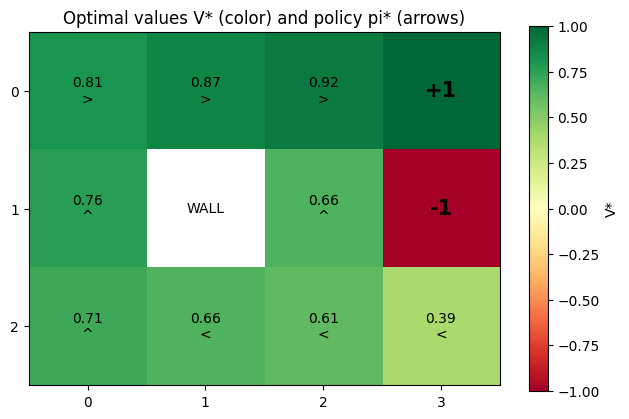

In [6]:
grid = np.full((ROWS, COLS), np.nan)
for s in states:
    grid[s] = V[s]
fig, ax = plt.subplots(figsize=(6.5, 4.2))
im = ax.imshow(grid, cmap="RdYlGn", vmin=-1, vmax=1)
for r in range(ROWS):
    for c in range(COLS):
        s = (r, c)
        if s == WALL:
            ax.text(c, r, "WALL", ha="center", va="center")
        elif s in TERMINALS:
            ax.text(c, r, f"{TERMINALS[s]:+.0f}", ha="center", va="center", fontsize=15, fontweight="bold")
        else:
            ax.text(c, r, f"{V[s]:.2f}\n{ARROW[greedy(s, V)]}", ha="center", va="center")
ax.set_xticks(range(COLS)); ax.set_yticks(range(ROWS))
ax.set_title("Optimal values V* (color) and policy pi* (arrows)")
fig.colorbar(im, ax=ax, label="V*")
plt.tight_layout(); plt.show()

## Your Turn

### Exercise 1 -- From values V to action-values Q

`V*(s)` says how good a square is; `Q*(s, a)` says how good each *action* from that square is. They are
linked by `V*(s) = max_a Q*(s, a)`. Compute `Q*` for all four actions at the start square `(2, 0)` and
confirm the best one equals `V*` there.

In [7]:
# TODO: Q*(s, a) = R(s) + GAMMA * sum_s' P(s'|s,a) V*(s')   for the start square (2, 0).
#   start = (2, 0)
#   for a in ("N", "S", "E", "W"):
#       q = LIVING + GAMMA * sum(p * V[ns] for ns, p in transitions(start, a).items())
#       print(f"  Q(start, {a}) = {q:+.3f}")
#   print(f"  V(start) = {V[start]:+.3f} = max over a  -> greedy action {greedy(start, V)}")

<details><summary>Expected Output</summary>

~~~text
  Q(start, N) = +0.705
  Q(start, S) = +0.660
  Q(start, E) = +0.631
  Q(start, W) = +0.671
  V(start) = +0.705 = max over a  -> greedy action N
~~~

The four action-values rank the moves: North (0.705) is best, West (0.671) close behind, East (0.631)
worst because it heads toward the wall. The value of the square is exactly the value of its best action,
`V*(start) = max_a Q*(start, a) = Q*(start, N) = 0.705` -- which is why the policy arrow there points
North. `V` answers "how good is this square?"; `Q` answers "how good is each move?", and is what an agent
acts on.
</details>

### Exercise 2 -- How the reward shapes the policy

The -0.04 living reward made the robot cautious -- it detours around the pit. Make every step really
painful (`-2.0`) and re-solve: now the robot just wants the episode *over*. Re-run value iteration with
the new living reward and print the policy.

In [8]:
# TODO: re-solve with a steep per-step penalty and show how the optimal policy changes.
#   V_harsh, _ = value_iteration(-2.0)
#   print("optimal policy with living reward -2.0:")
#   for r in range(ROWS):
#       row = []
#       for c in range(COLS):
#           s = (r, c)
#           if s == WALL: row.append("#")
#           elif s in TERMINALS: row.append("+" if TERMINALS[s] > 0 else "-")
#           else: row.append(ARROW[greedy(s, V_harsh)])
#       print(" ".join(row))

<details><summary>Expected Output</summary>

~~~text
optimal policy with living reward -2.0:
> > > +
^ # > -
> > > ^
~~~

With a steep -2.0 per step, lingering is so costly that the robot dives for the **nearest** exit -- even
the -1 pit. The square left of the pit now points **East straight into it** (it was North, avoiding it,
at -0.04), and the bottom-right square points up into the pit too. Same environment, same dynamics --
only the reward changed, and the optimal behaviour flipped from cautious to reckless. **Reward design
is how you tell an agent what you actually want;** get it wrong and the "optimal" policy does something
you never intended.
</details>

## Summary

- A **Markov Decision Process** is the tuple (states, actions, transition probabilities `P(s'|s,a)`,
  rewards `R`, discount `gamma`). Our gridworld has 11 states, 4 noisy actions (0.8 / 0.1 / 0.1), a +1
  and a -1 terminal, and a -0.04 living reward.
- **Value iteration** applies the **Bellman optimality** update -- a square's value is its reward plus
  the discounted best expected next value -- until the numbers settle (36 sweeps), giving `V*` that
  matches the Russell & Norvig textbook exactly.
- The **optimal policy** `pi*` is the greedy action over `V*`: drive to the goal, and route *around* the
  -1 pit rather than risk a slip into it.
- `V*(s) = max_a Q*(s, a)` (Ex1): the value of a square is the value of its best action; `Q` is what an
  agent acts on.
- **Reward shapes behaviour** (Ex2): a steep -2.0 living reward flips the policy from cautious to
  diving-into-the-pit -- reward design is how you specify the goal.
- Here we *knew* the model (P and R) and computed the answer directly. When the agent does **not** know
  the environment and must learn from experience -- **Q-learning**, **TD**, **policy gradients** on
  Gym/CartPole -- that is the hands-on track in **CDAT 4013 section 14**. That closes CDAT 4011.